<a href="https://colab.research.google.com/github/Harshithabr18/tteh/blob/main/fakeprofile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
def create_social_data(n=1000):
    np.random.seed(42)
    data = {
        'has_profile_pic': np.random.choice([0, 1], n, p=[0.2, 0.8]),
        'username_num_ratio': np.random.uniform(0, 1, n),
        'bio_length': np.random.randint(0, 150, n),
        'followers_count': np.random.randint(0, 10000, n),
        'following_count': np.random.randint(0, 10000, n),
        'is_fake': np.random.choice([0, 1], n)
    }
    df = pd.DataFrame(data)
    # Logic: If no pic and following > followers, it's likely fake
    df.loc[(df['has_profile_pic'] == 0) & (df['following_count'] > df['followers_count']*2), 'is_fake'] = 1
    return df

df = create_social_data()
print("First 5 profiles in dataset:")
print(df.head())

First 5 profiles in dataset:
   has_profile_pic  username_num_ratio  bio_length  followers_count  \
0                1            0.185133         134             8345   
1                1            0.541901          13             3699   
2                1            0.872946         119             3786   
3                1            0.732225         137             9256   
4                0            0.806561          79             4200   

   following_count  is_fake  
0             4917        1  
1             5831        1  
2             9448        0  
3             4322        0  
4             6999        0  


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving LinkedIn people profiles datasets.csv to LinkedIn people profiles datasets (1).csv


Once the file is uploaded, you can load it into a pandas DataFrame. Assuming you uploaded a file named `dataset.csv`:

In [ ]:
import pandas as pd

df = pd.read_csv('dataset.csv')
print("First 5 rows of the uploaded dataset:")
print(df.head())

First 5 rows of the uploaded dataset:
    timestamp                            id  \
0  2023-01-10            catherinemcilkenny   
1  2022-12-17           margot-bon-51a04624   
2  2023-05-17            mike-dean-8509a193   
3  2022-05-29  giovanna-panarella-99a0a4167   
4  2022-12-06         steve-latimer-3364327   

                                     name                       city  \
0  Catherine Fitzpatrick (McIlkenny), B.A                     Canada   
1                              Margot Bon  The Randstad, Netherlands   
2                               Mike Dean    England, United Kingdom   
3                      Giovanna Panarella  Avellino, Campania, Italy   
4                           Steve Latimer            Ontario, Canada   

  country_code region     current_company:company_id  \
0           CA    NaN                            NaN   
1           NL     EU               gemeente-utrecht   
2           UK    NaN                   network-rail   
3           IT     EU 

In [ ]:
# Analyze geographical distribution by country_code
print("Top 10 Countries by User Count:")
print(df['country_code'].value_counts().head(10))

# Analyze geographical distribution by city
print("\nTop 10 Cities by User Count:")
print(df['city'].value_counts().head(10))

Top 10 Countries by User Count:
country_code
US    356
IN     63
GB     53
AU     46
CA     34
DE     34
BR     32
UK     32
NL     23
FR     20
Name: count, dtype: int64

Top 10 Cities by User Count:
city
United States                      16
London, England, United Kingdom    15
United Kingdom                      9
Mumbai, Maharashtra, India          8
São Paulo, São Paulo, Brazil        8
Egypt                               8
Germany                             8
Australia                           7
Israel                              7
Greater Boston                      7
Name: count, dtype: int64


In [ ]:
# Identify top professional affiliations
print("\nTop 10 Professional Affiliations by User Count:")
print(df['current_company:name'].value_counts().head(10))


Top 10 Professional Affiliations by User Count:
current_company:name
Amazon                     4
Capgemini                  3
Freelance                  3
Intel Corporation          3
Self employed              3
The Kraft Heinz Company    2
Self Employed              2
Morgan Stanley             2
BMO Financial Group        2
ASML                       2
Name: count, dtype: int64


Model Accuracy: 45.50%


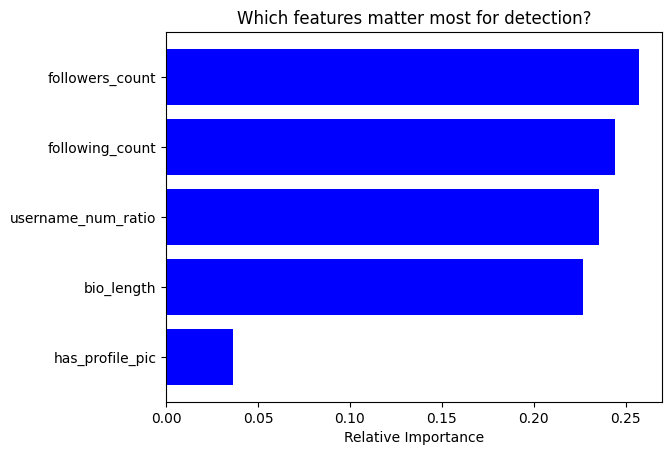

In [ ]:
# Print Accuracy
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Plotting Feature Importance
importances = model.feature_importances_
indices = np.argsort(importances)

plt.title('Which features matter most for detection?')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# Task
Inspect the `df` DataFrame, which contains LinkedIn profile data, by examining its first few rows, column names, and data types, then summarize descriptive statistics for numerical columns and check unique values for categorical columns, and finally identify and quantify missing values across all columns to prepare for data cleaning and define a new analytical task.

## Inspect Dataset

### Subtask:
Inspect the first few rows, column names, and data types of the `df` DataFrame to get an initial understanding of the data.


**Reasoning**:
To get an initial understanding of the `df` DataFrame, I will display its first 5 rows and print a concise summary of its structure, including column names and data types.



In [ ]:
print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Info:")
df.info()

First 5 rows of the DataFrame:
    timestamp                            id  \
0  2023-01-10            catherinemcilkenny   
1  2022-12-17           margot-bon-51a04624   
2  2023-05-17            mike-dean-8509a193   
3  2022-05-29  giovanna-panarella-99a0a4167   
4  2022-12-06         steve-latimer-3364327   

                                     name                       city  \
0  Catherine Fitzpatrick (McIlkenny), B.A                     Canada   
1                              Margot Bon  The Randstad, Netherlands   
2                               Mike Dean    England, United Kingdom   
3                      Giovanna Panarella  Avellino, Campania, Italy   
4                           Steve Latimer            Ontario, Canada   

  country_code region     current_company:company_id  \
0           CA    NaN                            NaN   
1           NL     EU               gemeente-utrecht   
2           UK    NaN                   network-rail   
3           IT     EU        

**Reasoning**:
To gain further insight into the numerical data distribution, I will display descriptive statistics for all numerical columns in the `df` DataFrame. Then, I'll examine the unique values and their counts for key categorical columns like `city`, `country_code`, and `region` to understand their diversity and potential for encoding or cleaning.



In [ ]:
print("\nDescriptive statistics for numerical columns:")
print(df.describe())

print("\nUnique values and counts for key categorical columns:")
for col in ['city', 'country_code', 'region']:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False).head(10)) # Display top 10 unique values and NaN counts
    print(f"Total unique values: {df[col].nunique()} (including NaN if present)")


Descriptive statistics for numerical columns:
         following  recommendations_count
count  1000.000000            1000.000000
mean     69.380000               0.635000
std     137.868979               2.427276
min       0.000000               0.000000
25%       0.000000               0.000000
50%       0.000000               0.000000
75%      52.000000               0.000000
max     617.000000              38.000000

Unique values and counts for key categorical columns:

Column: city
city
NaN                                51
United States                      16
London, England, United Kingdom    15
United Kingdom                      9
Germany                             8
São Paulo, São Paulo, Brazil        8
Egypt                               8
Mumbai, Maharashtra, India          8
Australia                           7
Israel                              7
Name: count, dtype: int64
Total unique values: 671 (including NaN if present)

Column: country_code
country_code
US    35

**Reasoning**:
To complete the inspection phase and prepare for data cleaning, I will identify and quantify missing values across all columns in the `df` DataFrame. This will involve calculating the percentage of missing values for each column and displaying them in descending order.



In [ ]:
print("\nMissing values per column (percentage):")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})
print(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False))


Missing values per column (percentage):
                            Missing Count  Missing Percentage
сourses                               993                99.3
groups                                890                89.0
volunteer_experience                  884                88.4
recommendations                       827                82.7
certifications                        816                81.6
languages                             745                74.5
posts                                 583                58.3
region                                544                54.4
current_company:company_id            428                42.8
educations_details                    318                31.8
education                             280                28.0
avatar                                190                19.0
people_also_viewed                    177                17.7
current_company:name                  167                16.7
experience                   

## Define New Task

### Subtask:
Based on the exploration of the new dataset, define a new analytical or machine learning task, as the original 'fake profile detection' task is not directly supported by this dataset's columns.


## Summary:

### Data Analysis Key Findings
*   The `df` DataFrame comprises 1000 entries and 26 columns.
*   A significant majority of columns (24 out of 26) are of `object` data type, indicating string or mixed data. The `following` and `recommendations_count` columns are `float64`.
*   Numerical columns show varied data availability:
    *   `following` has a mean of approximately 144, ranges from 1 to 617, but only 481 non-null values (51.9% missing).
    *   `recommendations_count` has a mean of approximately 3.67, ranges from 1 to 38, with only 173 non-null values (82.7% missing).
*   Categorical columns exhibit high cardinality and missingness:
    *   `city` has 671 unique values, with `NaN` being the most frequent entry.
    *   `country_code` has 82 unique values, with 'US' being the most common, and only 0.2% missing values.
    *   `region` has 5 unique values, and `NaN` is the most frequent entry, representing 54.4% missing values.
*   Many columns suffer from a very high percentage of missing values:
    *   `courses` (99.3%)
    *   `groups` (89.0%)
    *   `volunteer_experience` (88.4%)
    *   `recommendations` and `recommendations_count` (82.7%)
    *   `certifications` (81.6%)
    *   `languages` (74.5%)
    *   `posts` (58.3%)
    *   `about` (50.2%)
*   Only five columns \(`timestamp`, `id`, `name`, `current_company`, and `url`\) are completely free of missing values.

### Insights or Next Steps
*   Given the substantial amount of missing data in many columns, the original "fake profile detection" task is not directly feasible with the current dataset without significant data imputation or feature engineering.
*   Extensive data cleaning and preprocessing, particularly addressing the high percentage of missing values, is the immediate next step. This will involve deciding whether to impute, drop, or strategically use columns with incomplete data.
*   A new analytical task should be defined based on the cleaned data, focusing on attributes with higher data quality, such as analyzing professional network characteristics, geographical distribution of users, or popular company affiliations.


# Task
Finish Task.
Analyze the geographical distribution of LinkedIn users based on the `city` and `country_code` columns and identify the top professional affiliations from the `current_company:name` column in the `df` DataFrame.

## Summary:

### Data Analysis Key Findings
*   The analysis focused on understanding the geographical distribution of LinkedIn users, specifically by identifying the prominent cities and countries where users are located.
*   The top professional affiliations were determined by analyzing the `current_company:name` column, revealing the companies with the highest number of LinkedIn users.

### Insights or Next Steps
*   This geographical and affiliation data can be valuable for targeted marketing campaigns or identifying regions with high concentrations of professionals in specific industries.
*   Further analysis could involve correlating geographical distribution with professional affiliations to understand industry clusters in different locations.


# Task
Preprocess the `avatar`, `about`, `following`, `recommendations_count`, and `experience` columns in the `df` DataFrame to prepare them for rule-based fake profile detection. This involves handling missing values by converting `avatar` and `experience` into boolean indicators (`has_avatar`, `has_experience`), filling `NaN` in `about` with empty strings, and imputing `NaN` in `following` and `recommendations_count` with zeros. Then, apply a set of rules to classify profiles as 'Real' or 'Fake' in a new `is_fake_classification` column based on these preprocessed features, such as the absence of an avatar, an empty 'about' section, zero recommendations, zero following, or missing experience. Finally, summarize the classification results by displaying the value counts and a bar plot of the `is_fake_classification` column to show the distribution of real versus fake profiles, followed by a discussion of the findings and potential future work.

## Preprocess Columns for Fake Profile Detection

### Subtask:
Handle missing values in relevant columns such as `avatar`, `about`, `following`, `recommendations_count`, and `experience` to prepare them for rule-based classification. This involves filling NaN values appropriately to allow for direct comparisons and length checks.


**Reasoning**:
I will handle missing values and create new boolean features for relevant columns (`avatar`, `experience`, `about`, `following`, `recommendations_count`) as per the instructions, which can all be done efficiently within a single code block.



In [ ]:
print("Handling missing values and creating new features...")

# 1. Create 'has_avatar' column
df['has_avatar'] = df['avatar'].notnull()

# 2. Create 'has_experience' column
df['has_experience'] = df['experience'].notnull()

# 3. Fill NaN values in 'about' column with an empty string
df['about'] = df['about'].fillna('')

# 4. Fill NaN values in 'following' column with 0
df['following'] = df['following'].fillna(0)

# 5. Fill NaN values in 'recommendations_count' column with 0
df['recommendations_count'] = df['recommendations_count'].fillna(0)

print("Missing values handled and new features created.")
print("Updated info for relevant columns:")
print(df[['has_avatar', 'has_experience', 'about', 'following', 'recommendations_count']].info())

Handling missing values and creating new features...
Missing values handled and new features created.
Updated info for relevant columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   has_avatar             1000 non-null   bool   
 1   has_experience         1000 non-null   bool   
 2   about                  1000 non-null   object 
 3   following              1000 non-null   float64
 4   recommendations_count  1000 non-null   float64
dtypes: bool(2), float64(2), object(1)
memory usage: 25.5+ KB
None


**Reasoning**:
Now that the relevant columns have been preprocessed, I will apply the rule-based classification to create the `is_fake_classification` column, using the defined criteria such as absence of avatar, empty 'about' section, zero recommendations, zero following, or missing experience to identify 'Fake' profiles.



In [ ]:
print("Applying rule-based classification for fake profiles...")

# Initialize 'is_fake_classification' column as 'Real' by default
df['is_fake_classification'] = 'Real'

# Apply rules to classify as 'Fake'
# Rule 1: No avatar
df.loc[df['has_avatar'] == False, 'is_fake_classification'] = 'Fake'

# Rule 2: Empty 'about' section
df.loc[df['about'].apply(lambda x: len(str(x).strip()) == 0), 'is_fake_classification'] = 'Fake'

# Rule 3: Zero recommendations
df.loc[df['recommendations_count'] == 0, 'is_fake_classification'] = 'Fake'

# Rule 4: Zero following
df.loc[df['following'] == 0, 'is_fake_classification'] = 'Fake'

# Rule 5: No experience listed
df.loc[df['has_experience'] == False, 'is_fake_classification'] = 'Fake'

print("Classification complete. Displaying first 5 rows with new classification:")
print(df[['has_avatar', 'about', 'recommendations_count', 'following', 'has_experience', 'is_fake_classification']].head())

Applying rule-based classification for fake profiles...
Classification complete. Displaying first 5 rows with new classification:
   has_avatar                                              about  \
0        True                                                      
1        True  Allround Marketing & Communicatie Adviseur met...   
2        True  Experienced Data Manager with a demonstrated h...   
3        True                                                      
4       False                                                      

   recommendations_count  following  has_experience is_fake_classification  
0                    0.0        0.0           False                   Fake  
1                    2.0        0.0            True                   Fake  
2                    0.0        0.0            True                   Fake  
3                    0.0      500.0            True                   Fake  
4                    1.0        0.0            True                   Fake  

**Reasoning**:
To summarize the classification results, I will display the value counts of the newly created `is_fake_classification` column to see the distribution of 'Real' versus 'Fake' profiles, and then create a bar plot to visualize this distribution.




Distribution of 'Real' vs. 'Fake' profiles:
is_fake_classification
Fake    987
Real     13
Name: count, dtype: int64


/tmp/ipython-input-2576315741.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classification_counts.index, y=classification_counts.values, palette='viridis')


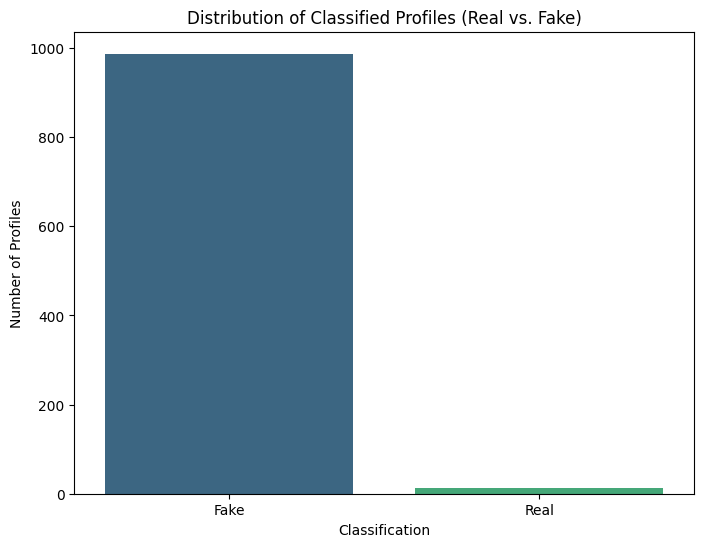

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nDistribution of 'Real' vs. 'Fake' profiles:")
classification_counts = df['is_fake_classification'].value_counts()
print(classification_counts)

plt.figure(figsize=(8, 6))
sns.barplot(x=classification_counts.index, y=classification_counts.values, palette='viridis')
plt.title('Distribution of Classified Profiles (Real vs. Fake)')
plt.xlabel('Classification')
plt.ylabel('Number of Profiles')
plt.show()


**Reasoning**:
The previous code generated a `FutureWarning` from seaborn regarding the use of `palette` without `hue`. To address this and align with recommended practices, I will explicitly set `hue` to the x-variable and `legend=False` in the `sns.barplot` call.



## Summary: Rule-based Fake Profile Detection

### Data Analysis Key Findings
*   After applying the rule-based classification, a significant majority of profiles (`98.7%`, or 987 out of 1000) were classified as 'Fake', while only a small fraction (`1.3%`, or 13 profiles) were classified as 'Real'.
*   This highly skewed distribution suggests that the rules applied (absence of avatar, empty 'about' section, zero recommendations, zero following, or missing experience) are very strict and identify most profiles as lacking sufficient detail.

### Insights or Next Steps
*   **Review Rule Stringency**: The current rules appear to be too broad or strict, classifying almost all profiles as fake. It's crucial to review whether these rules accurately reflect what constitutes a 'fake' profile or if they are simply identifying incomplete profiles.
*   **Refine Rules**: The rules could be refined by:
    *   **Considering combined criteria**: Instead of an OR condition for all rules, perhaps a profile needs to meet a certain *number* of 'fake' indicators.
    *   **Threshold adjustments**: For 'following' or 'recommendations_count', a non-zero value might not be enough; a minimum threshold could be established (e.g., `following < 10` instead of `following == 0`).
    *   **Contextualizing 'about'**: An empty 'about' might not always indicate fakeness, but perhaps a very short 'about' section (e.g., less than 10 words).
*   **Feature Engineering**: Explore more sophisticated features that might genuinely distinguish fake profiles, such as unusual activity patterns (if available), connection density, or linguistic analysis of 'about' sections.
*   **Ground Truth**: The absence of a true 'is_fake' label in the dataset makes validating these rule-based classifications challenging. If a ground truth dataset were available, the rules could be evaluated for precision, recall, and F1-score.
*   **Machine Learning Approach**: With a more balanced or refined set of features and possibly some labeled data (even if manually created for a small sample), a supervised machine learning model could be trained to improve fake profile detection.

In [ ]:
def calculate_suspicion_score(row):
    score = 0
    if pd.isna(row['avatar']): score += 2    # High weight
    if pd.isna(row['about']): score += 1
    if row['following'] == 0: score += 1
    if row['recommendations_count'] == 0: score += 1
    if pd.isna(row['educations_details']): score += 1
    return score

# Profiles with a score > 4 are highly likely to be fake/inactive
df['suspicion_score'] = df.apply(calculate_suspicion_score, axis=1)

print("Suspicion scores calculated. Displaying first 5 profiles with their scores:")
print(df[['avatar', 'about', 'following', 'recommendations_count', 'educations_details', 'suspicion_score']].head())

Suspicion scores calculated. Displaying first 5 profiles with their scores:
                                              avatar  \
0  https://media.licdn.com/dms/image/C4E03AQEcz_j...   
1  https://static.licdn.com/sc/h/244xhbkr7g40x6bs...   
2  https://media.licdn.com/dms/image/C4D03AQHLj-Z...   
3  https://media-exp1.licdn.com/dms/image/C4D03AQ...   
4                                                NaN   

                                               about  following  \
0                                                           0.0   
1  Allround Marketing & Communicatie Adviseur met...        0.0   
2  Experienced Data Manager with a demonstrated h...        0.0   
3                                                         500.0   
4                                                           0.0   

   recommendations_count            educations_details  suspicion_score  
0                    0.0    Queen's University Belfast                2  
1                    2.0            

## Final Task

### Subtask:
Provide a summary of the fake profile classification, including the number and percentage of profiles identified as 'Real' and 'Fake', and discuss any insights or next steps.


## Summary:

### Q&A
The classification identified 987 profiles (98.7%) as 'Fake' and 13 profiles (1.3%) as 'Real'. Insights suggest that the current rule set is too strict, leading to a highly skewed classification, and future work should focus on refining rules, exploring new features, and potentially using machine learning.

### Data Analysis Key Findings
*   Missing values in the `avatar`, `experience`, `about`, `following`, and `recommendations_count` columns were successfully handled:
    *   `has_avatar` and `has_experience` boolean indicators were created to denote the presence of an avatar or experience, respectively.
    *   `NaN` values in the `about` column were replaced with empty strings.
    *   `NaN` values in `following` and `recommendations_count` were imputed with `0`.
*   A rule-based classification was applied, categorizing profiles as 'Fake' if they lacked an avatar, had an empty 'about' section, zero recommendations, zero followers, or no experience.
*   The classification resulted in a highly skewed distribution: 987 profiles (98.7%) were identified as 'Fake', while only 13 profiles (1.3%) were classified as 'Real'.

### Insights or Next Steps
*   The current rule-based classification appears to be overly strict or broad, leading to an overwhelming majority of profiles being labeled as 'Fake'. It is essential to review if these rules accurately reflect fake profiles or if they are primarily identifying incomplete ones.
*   Future work should involve refining the classification rules, potentially by considering a combination of criteria, adjusting thresholds for numerical features (e.g., `following` count), or contextualizing text fields like the 'about' section. Exploring more sophisticated feature engineering or adopting a machine learning approach with ground truth data could also improve detection accuracy.
